In [ ]:
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import copy

# Cargamos los datos
X_test = np.load('../data/processed/X_test_AE.npy')
y_test = np.load('../data/processed/y_test.npy')
X_val_normal = np.load('../data/processed/X_val_normal.npy')
y_val = np.load('../data/processed/y_val.npy')
X_train_normal = np.load('../data/processed/X_train_normal.npy')
y_train = np.load('../data/processed/y_train.npy')

# Entrenamos el Autoencoder solo con casos normales (y == 0)
train_tensor = torch.FloatTensor(X_train_normal)
val_tensor = torch.FloatTensor(X_val_normal)

# DataLoader para entrenamiento eficiente
train_loader = DataLoader(train_tensor, batch_size=64, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=512, shuffle=True)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder: 29 -> 16 -> 8 -> 4
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )

        # Decoder: 4 -> 8 -> 16 -> 29
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim) # Sin ReLU final
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))



In [ ]:
model = Autoencoder(input_dim=29)
epochs = 100
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=1e-4)
patience = 10        # cuantas epochs esperar antes de parar
best_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
counter = 0

history_train = []
history_val = []

model.train() 
for epoch in range(epochs):  
    train_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad() # Resetrar el gradiente acumulado a 0

        # Añadimos ruido
        #noise = torch.rand_like(batch) * 0.01
        #batch_noise = batch + noise

        output = model(batch) # Forward Pass
        loss = criterion(output, batch) # Calculamos la perdida
        loss.backward() # Calculamos los gradientes
        optimizer.step() # Actualizamos los pesos
        train_loss += loss.item() # Acumulamos la perdida del batch
    history_train.append(loss.item())

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            recon = model(batch)
            loss_val = criterion(recon, batch)
            val_loss += loss_val.item()
    history_val.append(loss_val.item())
        
    model.train()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}',
              f'Val Loss: {val_loss/len(val_loader):.4f}')
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
# Cargar los mejores pesos
model.load_state_dict(best_model_wts)

Epoch [10/100], Loss: 0.6817 Val Loss: 0.6825
Epoch [20/100], Loss: 0.6393 Val Loss: 0.6407
Epoch [30/100], Loss: 0.6073 Val Loss: 0.6117
Epoch [40/100], Loss: 0.5800 Val Loss: 0.5843
Epoch [50/100], Loss: 0.5662 Val Loss: 0.5690
Epoch [60/100], Loss: 0.5524 Val Loss: 0.5543
Epoch [70/100], Loss: 0.5401 Val Loss: 0.5436
Epoch [80/100], Loss: 0.5340 Val Loss: 0.5367
Epoch [90/100], Loss: 0.5310 Val Loss: 0.5325
Epoch [100/100], Loss: 0.5288 Val Loss: 0.5309


<All keys matched successfully>

In [29]:
torch.save(model.state_dict(), "autoencoder.pth")


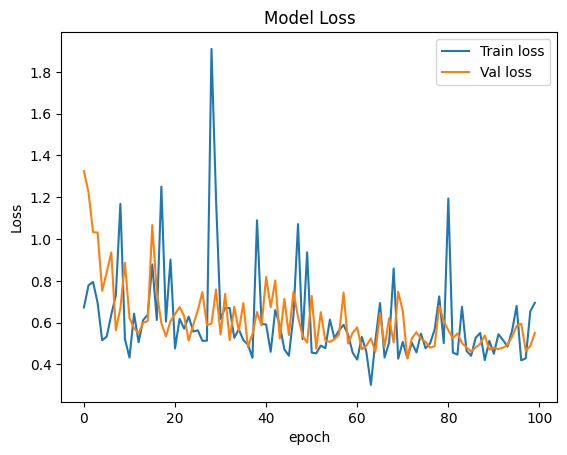

In [31]:
import matplotlib.pyplot as plt


plt.plot(history_train, label="Train loss")
plt.plot(history_val, label="Val loss")
plt.title('Model Loss')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Evaluamos el modelo con los datos de test
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test)
    recon = model(X_test_tensor)
    recon_error = ((recon - X_test_tensor) ** 2).mean(dim=1).numpy()


In [ ]:
# Frontera de decisión
threshold = recon_error.mean() + 3.7 * recon_error.std()

# Predicciones 0/1
y_pred = (recon_error >= threshold).astype(int)

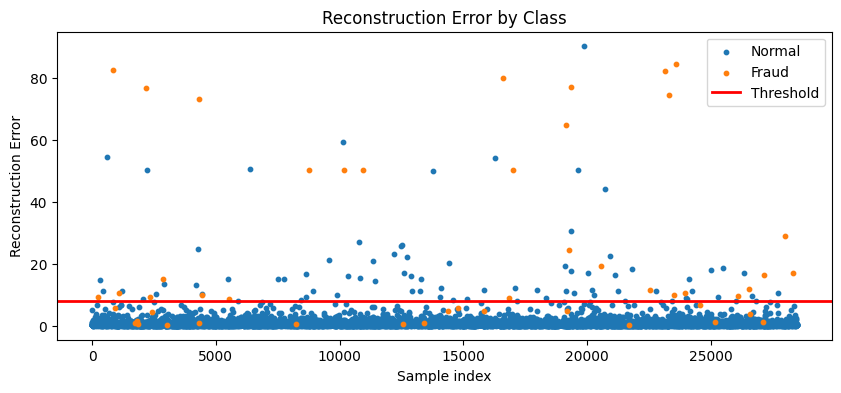

In [ ]:
import pandas as pd

error_df = pd.DataFrame({
    "recon_error": recon_error,  # salida del AE
    "true_class": y_test  # 0/1
})

groups = error_df.groupby("true_class")
fig, ax = plt.subplots(figsize=(10,4))

# Graficamos los puntos
for name, group in groups:
    ax.scatter(
        group.index,
        group.recon_error,
        s = 10,
        label="Fraud" if name == 1 else "Normal"
    )

# Graficamos la frontera de decisión
ax.axhline(threshold, color='r', linewidth=2, label='Threshold')

ax.set_title("Reconstruction Error by Class")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstruction Error")
ax.legend()
plt.show()

AUCPR: 0.3557745054616931


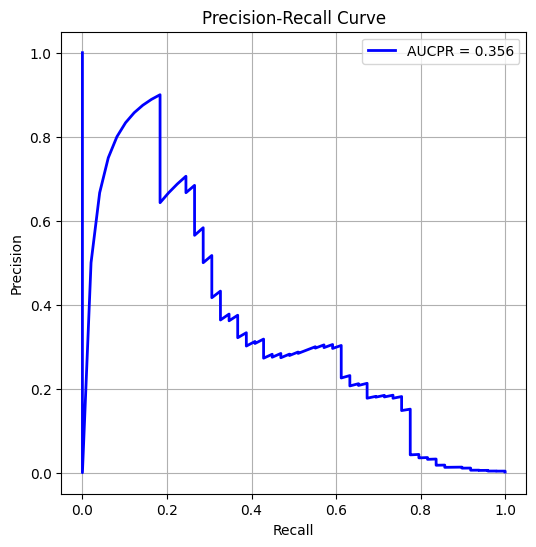

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# PR-AUC
precision, recall, thresholds = precision_recall_curve(y_test, recon_error)

aucpr = average_precision_score(y_test, recon_error)
print("AUCPR:", aucpr)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='b', lw=2, label=f'AUCPR = {aucpr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Precision: 0.28846153846153844
Recall: 0.6122448979591837


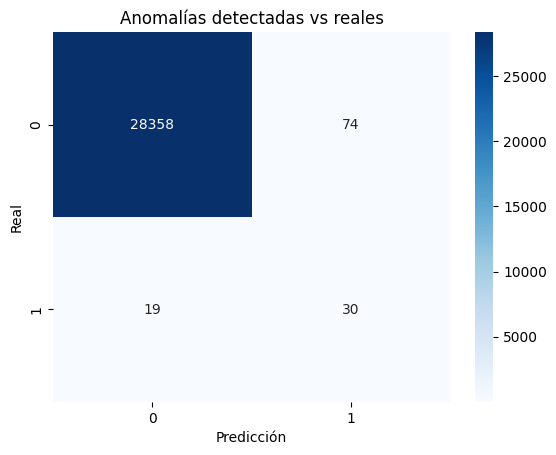

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
cm = confusion_matrix(y_test, y_pred)

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print("Precision:", precision)
print("Recall:", recall)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Anomalías detectadas vs reales")
plt.show()
